<a href="https://colab.research.google.com/github/olawaleaboderin/machine_learning/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pipeline for deep learning with PyTorch**

### Step 1: Data preparation

In [1]:
!pip install torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

In [2]:
# Define a transformation to flatten the 8x8 images
transform = transforms.Compose([
    transforms.Resize((8, 8)),         # Resize the PIL Image to 8x8 first (MNIST images are originally 28x28)
    transforms.ToTensor(),             # Then convert to tensor
    transforms.Lambda(lambda x: x.view(-1))  # Finally, flatten the tensor
])

# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 354kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.8MB/s]


**Question**. Dataloaders `train_loader` and `test_loader` are iterators which allow to access examples and labels.
- What is the type of objects yielded by the train and test dataloaders?
- What is the *shape* of `images` returned by `for images, labels in train_loader`? How do you interpret that shape?
- Why dataloaders for train and test differ with respect to the option `shuffle`?

**Prompt:** *Add a code cell to demonstrate the type and shape of objects returned by the train DataLoader.*

In [3]:
# Get one batch from the train loader
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Q1: Type of objects yielded by the dataloaders
print("Type of batch:", type((images, labels)))
print("Type of images:", type(images))
print("Type of labels:", type(labels))

# Q2: Shape of images
print("\nShape of images:", images.shape)
print("Shape of labels:", labels.shape)

Type of batch: <class 'tuple'>
Type of images: <class 'torch.Tensor'>
Type of labels: <class 'torch.Tensor'>

Shape of images: torch.Size([64, 64])
Shape of labels: torch.Size([64])


**Answer to Question 1 — DataLoaders**

**A. Type of objects yielded by the DataLoaders:**
Each iteration of `train_loader` or `test_loader` yields a **list containing two `torch.Tensor` objects**:
- `images` — dtype `torch.float32`, pixel values normalised to [0, 1].
- `labels` — dtype `torch.int64` (Long), integer class labels 0–9.

**B. Shape of `images` returned by `for images, labels in train_loader`:**

The shape is **`[64, 64]`**, i.e. `(batch_size, flattened_image_size)`.
- First dimension `64` = `batch_size` defined when creating the DataLoader.
- Second dimension `64` = 8 × 8 = 64 pixels per image after `transforms.Lambda(lambda x: x.view(-1))` flattens each image to a 1-D vector.

**C. Why does `train_loader` use `shuffle=True` but `test_loader` uses `shuffle=False`?**
- `shuffle=True` (training): Randomises the order of examples each epoch, preventing the model from overfitting to any particular ordering and ensuring mini-batches contain a diverse mix of classes, which stabilises gradient estimates.
- `shuffle=False` (test): During evaluation we only measure performance, we never update weights, so order is irrelevant. Keeping a fixed order also makes results reproducible and easier to debug.

#### Visualize some examples and labels

Since the `transform` that was applied above returns flattened tensors, one needs to unflatten them to be able to create an image that can be plotted.

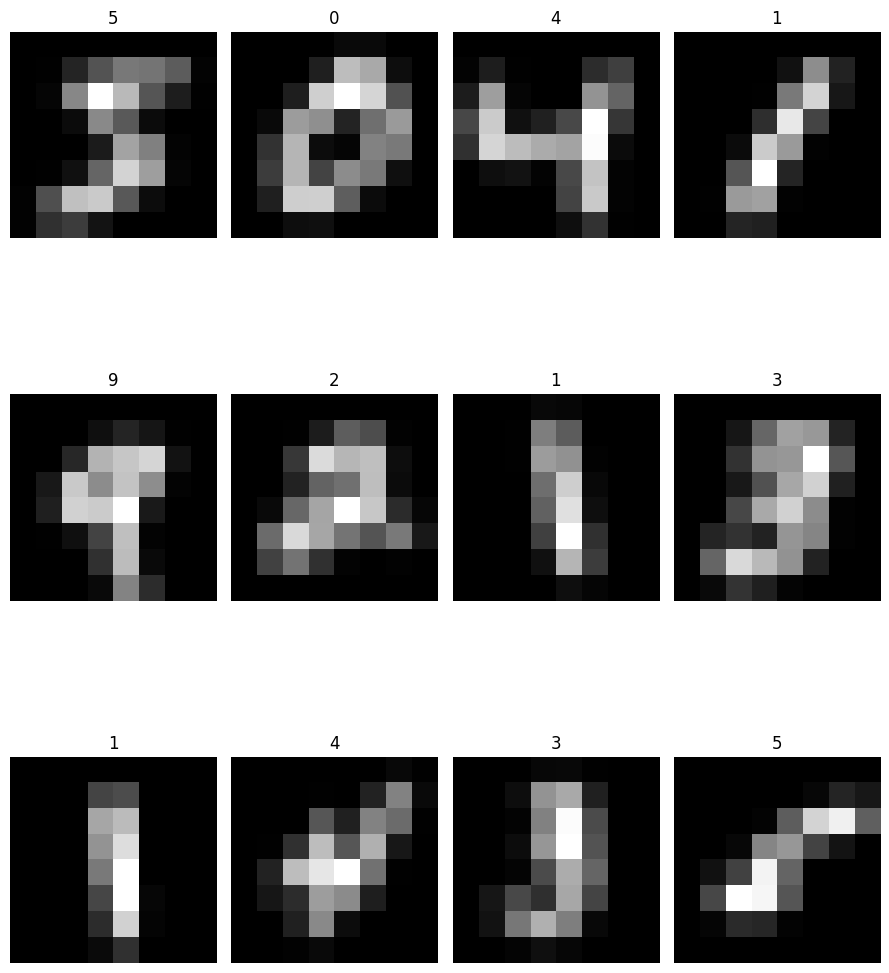

In [4]:
# Assuming each image is a 1D tensor of length 64 (8*8)
images, labels = zip(*[train_dataset[i] for i in range(12)]) # Visualize only the first 12 examples

fig, axes = plt.subplots(3, 4, figsize=(9, 12))
for i, ax in enumerate(axes.flat):
    img = images[i].reshape(8, 8)  # Unflatten to 2D
    ax.imshow(img, cmap='gray')
    ax.set_title(str(labels[i]), fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Step 2: model development

In [5]:
# Model Development: the model is a multilayer perceptron with one hidden layer
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Since we are using 8x8 MNIST and flatenning the input, the input size is 8 * 8 = 64
input_size = 8 * 8
hidden_size = 128
num_classes = 10 # 0-9 digits

model = SimpleNN(input_size, hidden_size, num_classes)

**Question**:
- The model architecture depends on the input data shape. The input images of MNIST are originally of size $28 \times 28$ but they have been resized to $8 \times 8$ pixels. Which changes do you need to do if you want to use the original $28 \times 28$ size? Indicate two changes you need to do in this notebook.
- Which change you need to do in the `SimpleNN` class if you want your model to have two hidden layers, both with size 128?
- What is a `ReLU` activation function called by `nn.ReLU`?
- Why are non linear activation functions like `ReLU` necessary for deep learning?

**Answer to Question 2**

**A. Two changes needed to use original 28×28 images:**
1. `transforms.Resize((8, 8))` should be removed in the transform (cell above).
2. `input_size = 8 * 8` should be changed in the model instantiation to `input_size = 28 * 28`.

**B. For the model to have two hidden layers (both with size 128)**: a second linear layer `nn.Linear` and a second ReLU activation `nn.ReLU` will be added in both  `__init__` and `forward()`.

class SimpleNN(nn.Module):

    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)   
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)  
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out

**C. What is ReLU?**
ReLU stands for Rectified Linear Unit. It is a very simple mathematical function defined as:

$f(x) = \max(0, x)$

It main purpose is to outputs the input unchanged if positive, and zero otherwise.

**C. Why are non-linear activations necessary?**
Non-linear activation functions like ReLU are necessary for deep learning because without them, stacking multiple layers would be mathematically equivalent to having just a single linear layer, no matter how deep the network is. This is because composing linear transformations always produces another linear transformation, meaning additional layers would add no extra learning capacity.

In [6]:
# Loss and optimizer: necessary for training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### Some details about cross entropy, softmax, one hot encoding and distributions

Since the problem is a *classification problem*, the criterion to compare model predictions with actual labels (what was denoted be $y$ and $\hat{y}$ for regression) is typically `criterion = nn.CrossEntropyLoss()`. This function has two arguments:
1. the output of the model (a list of scores returned by the model for each possible class, where the largest score corresponds to the most likely class) and
2. the target, which is the actual label of example. For instance if there are 10 classes $0, 1, \dots, 9$, the output would be a list like $[0.3,1.2,2.5,0.2,...]$ with 10 values, and the target could be 2 for instance.

The `nn.CrossEntropyLoss()` function will internally process the scores an the target the following way.

1. **Scores**. The unormalized model outputs $f_1, \dots, f_k$ are called *scores*, *logits* or *raw* outputs. Each score $z_i=f_i({\rm \bf x};{\rm \bf w_i})$ is converted into a [0,1] value by the *softmax* function:
$$p_i=\frac{\exp(z_i)}{\sum_{j=1}^k \exp(z_j)} ~~ {\rm which~implies~that} ~~ 0<p_i \le 1.$$
After that transformation, the classification model's probabilistic output is a vector of values $(p_1,\dots,p_k)$, with $p_i \ge 0$ and $\sum p_i=1$ as required for  probability distributions. The predicted label is the one with highest $p$.

<img src="https://drive.google.com/uc?export=view&id=1iD519g8QbBmOGp9SiOQsIneJnWg53SMQ" width="600" >


2. **Target**. A target value of, say, 2 is one-hot-encoded into the list $[0,0,1,0,...,0]$ of length 10.

The **cross-entropy loss** measures the dissimilarity between the probability distribution returned by *softmax* $(p_1,p_2,\dots)$ and the one hor encoded target distribution $(t_1,t_2,\dots)$ for each example. Its value range from 0 (optimal value associated to minimum uncertainty) and 1 (maximum value associated to maximum uncertainty, i.e. all probabilities are equal):

$$L_{single~example}=-\left( t_1 \, \log(p_1) + t_2 \, \log(p_2) + \dots \right) \in [0,1].$$

In the expression above, we suppose that the probabilities $p_i$ are non zero which is guaranteed by the *softmax* function.

For a batch of $n$ examples, the cross-entropy loss is given by the average of the $n$ individual loss values, where $L_i$ is the cross entropy for the $i$th example:

$$L_{batch}=\frac{1}{n} \left( L_1+L_2+ \dots,L_n\right).$$


### Step 3: Model training

In [7]:
# number of epochs
num_epochs = 3

#### Typical training loop

In [8]:
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


epoch: 1; time: 1779224196
epoch: 2; time: 1779224205
epoch: 3; time: 1779224214


**Question**. Does processing time decreases if you add the option `num_workers=2` when defining the dataloader? Compute training time with and without that option and show the results for comparison.




**Prompt:** *Add code to compare training time with num_workers=0 vs num_workers=2 for the DataLoader, printing both results for direct comparison.*

In [9]:
import time

# --- Training function ---
def train(loader, model, optimizer, criterion, num_epochs):
    model.train()
    for epoch in range(num_epochs):
        for images, labels in loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

# --- Setup ---
num_epochs = 5

# Without num_workers
loader_nw = DataLoader(train_dataset, batch_size=batch_size,
                       shuffle=True, num_workers=0)
model_nw = SimpleNN(input_size, hidden_size, num_classes)
optimizer_nw = optim.Adam(model_nw.parameters(), lr=0.001)

start = time.time()
train(loader_nw, model_nw, optimizer_nw, criterion, num_epochs)
time_nw = time.time() - start

# With num_workers=2
loader_ww = DataLoader(train_dataset, batch_size=batch_size,
                       shuffle=True, num_workers=2)
model_ww = SimpleNN(input_size, hidden_size, num_classes)
optimizer_ww = optim.Adam(model_ww.parameters(), lr=0.001)

start = time.time()
train(loader_ww, model_ww, optimizer_ww, criterion, num_epochs)
time_ww = time.time() - start

# --- Results ---
print(f"Training time  num_workers=0 : {time_nw:.2f}s")
print(f"Training time  num_workers=2 : {time_ww:.2f}s")
print(f"Difference                   : {abs(time_nw - time_ww):.2f}s")

if time_ww < time_nw:
    print(f"num_workers=2 is FASTER by {time_nw - time_ww:.2f}s")
else:
    print(f"num_workers=2 is SLOWER by {time_ww - time_nw:.2f}s")

Training time  num_workers=0 : 46.73s
Training time  num_workers=2 : 49.87s
Difference                   : 3.13s
num_workers=2 is SLOWER by 3.13s


 **Answer to question 3**

Adding num_workers=2 did not reduce training time. The results show that it did not improve training speed, in fact it was slightly slower. This can be explained by two reasons.

First, the dataset is too small and simple to benefit from parallel loading. The images have been resized to 8×8 pixels and flattened into vectors of 64 numbers, meaning each image is extremely lightweight and loads almost instantly. The main process alone can keep up with the model's demand for data without any delay, so there is no bottleneck for extra workers to solve.

Second, parallel workers carry an overhead cost. Launching num_workers=2 means Python has to spin up 2 separate background processes and coordinate data transfer between them and the main process. This coordination cost occurs every epoch regardless of dataset size, and when data loading is already near-instant, the overhead ends up costing more time than it saves.

#### Change device: run training on GPU

Training involves many large matrix computations. In general, this is done faster if it is parellelized over multiple cores. One can determine which device, either `cuda` (for GPU) or `cpu`, is used for training. Both model and data must be moved to the right device.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device) #<<<<<<<<<< move model to device

# Re-initialize the optimizer after moving the model to the device
optimizer = optim.Adam(model.parameters(), lr=0.001)

#move data to GPU
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Using device: cuda
epoch: 1; time: 1779224344
epoch: 2; time: 1779224354
epoch: 3; time: 1779224363
epoch: 4; time: 1779224372
epoch: 5; time: 1779224382


### Step 4: Validation

Validation is important for several goals, including:
- to estimate the accuracy of the model for the task at hand;
- to determine the optimal number of iterations (epochs);
- to be able to tune the model choosing the best hyperparameters.

Below, we will concentrate on the first two of those issues, and we will compare the estimated overall accuracy over the train and the test sets. In order to do this need to keep track of the intermediate results for each epoch and each batch of examples.

In [11]:
# Model Training
num_epochs = 5

# Computes the accuracy for a batch: outputs are probability-like values
def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = len(labels)
    return correct / total

# History object to keep track of accuracy along epochs
history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    batch_accuracies=[]
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # compute accuracy over the batch
        batch_accuracies.append(compute_accuracy(outputs, labels))
    history['epoch'].append(epoch)
    history['train_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

    # Validation phase
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.eval()
    batch_accuracies=[]
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)  #<<<<<<<<<< move data to device
            labels = labels.to(device)  #<<<<<<<<<< move data to device
            outputs = model(images)
            # compute accuracy over the batch
            batch_accuracies.append(compute_accuracy(outputs, labels))
        history['val_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

epoch: 1; time: 1779224412
epoch: 1; time: 1779224422
epoch: 2; time: 1779224423
epoch: 2; time: 1779224433
epoch: 3; time: 1779224434
epoch: 3; time: 1779224444
epoch: 4; time: 1779224445
epoch: 4; time: 1779224455
epoch: 5; time: 1779224456
epoch: 5; time: 1779224465


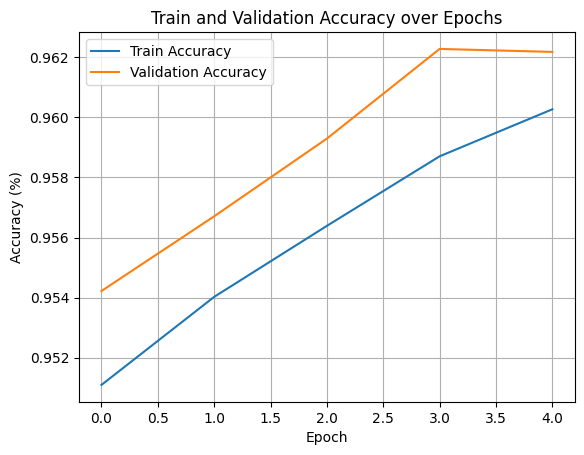

In [12]:
# accuracy plot
plt.plot(history['epoch'], history['train_accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

**Question**:
- From the visualization of that plot, do you think that 5 epochs are enough, or should the model train longer than that?
- Can you find a reason for the validation curve to be consistently higher than the training curve, which in principle should not happen. Hint: look at how the history for train and validation are computed during model training, and correct the plot construction.



 **Answer to question 4**

A. No, five epochs are not enough. Looking at the plot, the training curve (blue) is still climbing steadily at epoch 4 and hasn't flattened. This means the model is still learning and has not reached its best performance. The model would benefit from more training.

B. The validation curve is consistently higher than the training curve because of a timing error in how the training accuracy was being computed. In the original code, training accuracy was recorded batch by batch throughout the epoch and then averaged. This means the accuracy from the first batch when the model was at its weakest point in that epoch, was averaged together with the accuracy from the last batch, when the model was at its strongest. This pulls the average down artificially.

The validation accuracy, on the other hand, was measured once at the very end of the epoch using `model.eval()` on the fully updated model, meaning it always reflected the model in its best and most current state for that epoch.
This timing mismatch created an unfair comparison between the two curves, causing validation accuracy to appear consistently higher than training accuracy. The fix is to compute training accuracy in a separate evaluation pass after all weight updates are complete, mirroring exactly how validation accuracy is computed.

**Prompt:** *Fix the training loop so that training accuracy is computed in a separate evaluation pass after training, matching the validation accuracy computation. Then re-plot both curves for a fair comparison.*

Epoch  1 | Train: 0.8895 | Val: 0.8963
Epoch  2 | Train: 0.9082 | Val: 0.9119
Epoch  3 | Train: 0.9229 | Val: 0.9252
Epoch  4 | Train: 0.9307 | Val: 0.9347
Epoch  5 | Train: 0.9376 | Val: 0.9406
Epoch  6 | Train: 0.9433 | Val: 0.9457
Epoch  7 | Train: 0.9477 | Val: 0.9505
Epoch  8 | Train: 0.9517 | Val: 0.9541
Epoch  9 | Train: 0.9532 | Val: 0.9569
Epoch 10 | Train: 0.9576 | Val: 0.9586
Epoch 11 | Train: 0.9568 | Val: 0.9588
Epoch 12 | Train: 0.9622 | Val: 0.9626
Epoch 13 | Train: 0.9644 | Val: 0.9658
Epoch 14 | Train: 0.9654 | Val: 0.9654
Epoch 15 | Train: 0.9674 | Val: 0.9670


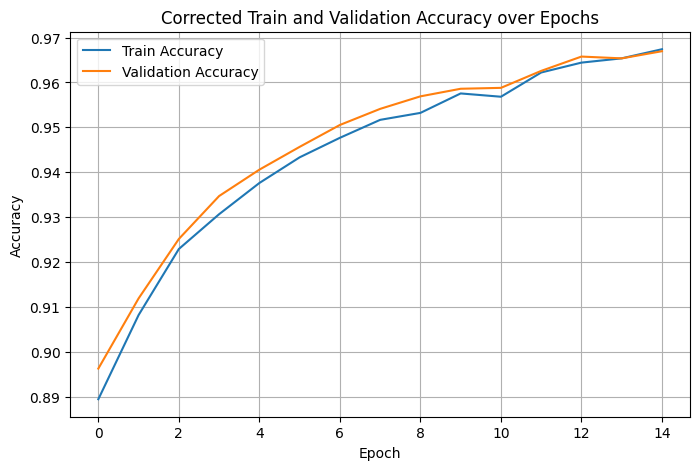

In [13]:
# Re-initialise model and optimizer for a clean run
model = SimpleNN(input_size, hidden_size, num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 15  # more epochs to see convergence

history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    # --- training phase ---
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # --- evaluate train accuracy AFTER all updates ---
    model.eval()
    batch_accuracies = []
    with torch.no_grad():
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            batch_accuracies.append(compute_accuracy(outputs, labels))
    history['train_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

    # --- validation phase ---
    batch_accuracies = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            batch_accuracies.append(compute_accuracy(outputs, labels))
    history['val_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

    history['epoch'].append(epoch)
    print(f"Epoch {epoch+1:2d} | Train: {history['train_accuracy'][-1]:.4f} | Val: {history['val_accuracy'][-1]:.4f}")

# --- corrected plot ---
plt.figure(figsize=(8, 5))
plt.plot(history['epoch'], history['train_accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Corrected Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

After correcting the plot construction by computing training accuracy in a separate evaluation pass after all weight updates are complete (mirroring exactly how validation accuracy is computed), the plot now shows the expected behaviour. Training accuracy is consistently equal to or higher than validation accuracy from epoch 9 onwards, confirming that the original anomaly was entirely due to the timing mismatch in how training accuracy was recorded. Both curves rise steeply in the early epochs, reflecting rapid learning, and then flatten progressively as the model approaches convergence. By epoch 15, the improvements between consecutive epochs are smaller than 0.002, indicating that the model has largely converged and additional epochs would yield diminishing returns.